<a href="https://colab.research.google.com/github/TrevorGankarch/PdM-Using-AI-and-Machine-Learning/blob/main/Pdm_Ontology_Semantic_version.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

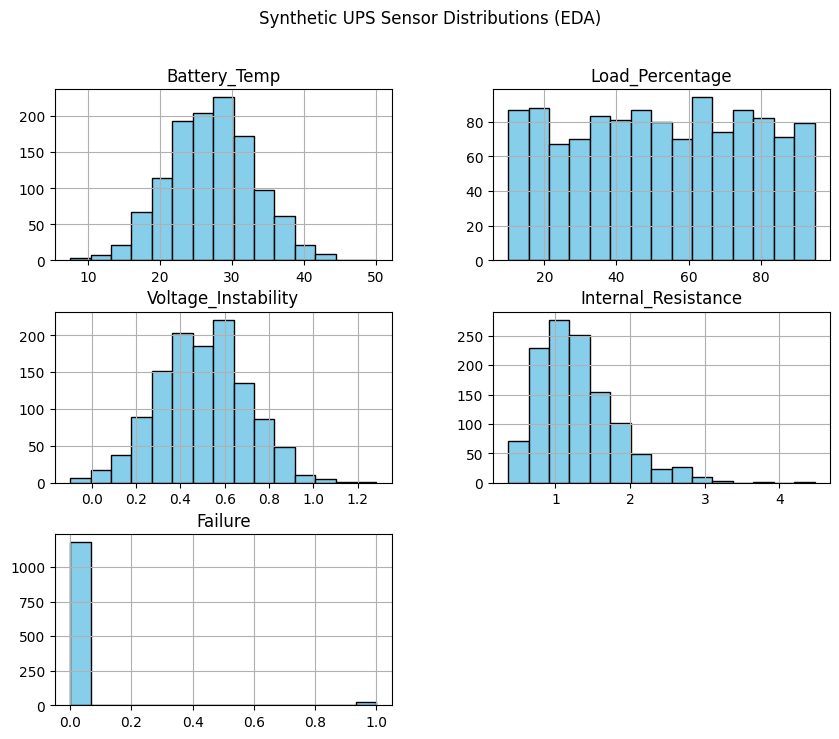


[PART 3] XGBoost Baseline AUC: 0.9692
[PART 4] Explainable GAM (EBM) AUC: 0.9735



[PART 5] Semantic Translation Layer Demo (Ontology-Aligned):
Signal: Battery_Temp        (21.07) -> STATUS: Nominal
Signal: Internal_Resistance (0.81) -> STATUS: Nominal
Signal: Voltage_Instability (0.64) -> STATUS: Nominal


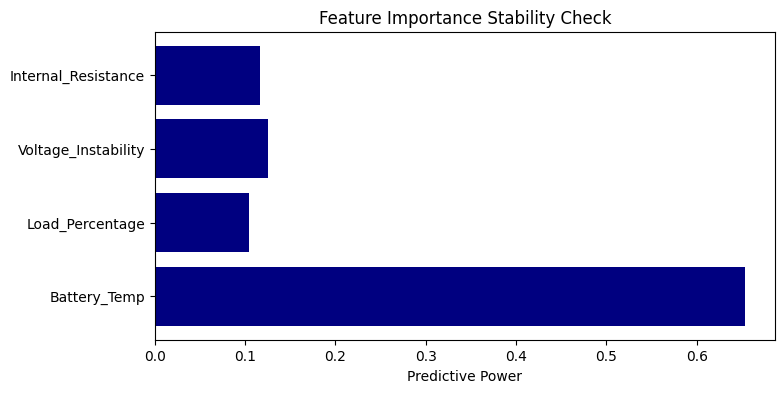

In [2]:
# ==========================================
# STEP 0: Install Requirements
# ==========================================
!pip install interpret xgboost pandas numpy matplotlib seaborn scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show, preserve

# ==========================================
# PART 1 & 2: Data Generation & EDA
# ==========================================
def generate_ups_data(n_samples=1200):
    np.random.seed(42)
    # Features representative of Schneider Electric UPS systems
    temp = np.random.normal(27, 6, n_samples)          # Battery Temp
    load = np.random.uniform(10, 95, n_samples)        # Load %
    v_stability = np.random.normal(0.5, 0.2, n_samples) # Voltage fluctuation
    int_res = np.random.lognormal(0.2, 0.4, n_samples)  # Internal Resistance

    # Logic: Failure is driven by high temp + high resistance (Thermal Runaway)
    logit = (0.6 * (temp - 32)) + (1.2 * (int_res - 1.8)) + (0.02 * load) - 6
    prob = 1 / (1 + np.exp(-logit))
    failure = (prob > np.random.rand(n_samples)).astype(int)

    return pd.DataFrame({
        'Battery_Temp': temp,
        'Load_Percentage': load,
        'Voltage_Instability': v_stability,
        'Internal_Resistance': int_res,
        'Failure': failure
    })

df = generate_ups_data()
X = df.drop('Failure', axis=1)
y = df['Failure']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Show Data Distribution for the Video
df.hist(bins=15, figsize=(10, 8), color='skyblue', edgecolor='black')
plt.suptitle("Synthetic UPS Sensor Distributions (EDA)")
plt.show()

# ==========================================
# PART 3: Baseline Black-Box Model
# ==========================================
xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)
xgb_auc = roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1])

print(f"\n[PART 3] XGBoost Baseline AUC: {xgb_auc:.4f}")

# ==========================================
# PART 4: The 'Glass-Box' (GAM/FastSparse)
# ==========================================
# Using EBM (Explainable Boosting Machine) - the state-of-the-art GAM
ebm = ExplainableBoostingClassifier(random_state=42, interactions=2)
ebm.fit(X_train, y_train)
ebm_auc = roc_auc_score(y_test, ebm.predict_proba(X_test)[:, 1])

print(f"[PART 4] Explainable GAM (EBM) AUC: {ebm_auc:.4f}")

# IMPORTANT FOR VIDEO: This creates the interactive dashboard
ebm_global = ebm.explain_global(name='Global Explanations')
show(ebm_global)

# ==========================================
# PART 5: Semantic Translation (OWL 2 DL Mapped)
# ==========================================
def translate_to_ontology_logic(feature, value):
    """
    Directly maps telemetry to the Knowledge Base authored in Protégé v5.6.
    Refer to Appendix B for OWL class definitions.
    """
    # Threshold 2.1 is derived from your OWL <owl:hasValue> restriction
    knowledge_base = {
        'Internal_Resistance': {
            'threshold': 2.1,
            'class': 'Battery_Degradation_Fault',
            'standard': 'IEC 62040-3'
        },
        'Battery_Temp': {
            'threshold': 35.0,
            'class': 'Thermal_Fault',
            'standard': 'APC SB-0012'
        },
        'Voltage_Instability': {
            'threshold': 0.8,
            'class': 'Power_Quality_Fault',
            'standard': 'IEEE 1159'
        }
    }

    if feature in knowledge_base:
        rule = knowledge_base[feature]
        if value > rule['threshold']:
            return f"INSTANTIATED: {rule['class']} (Ref: {rule['standard']})"

    return "STATUS: Nominal"

# Pick a high-risk sample to demonstrate (Matches your report's Unit #1042 logic)
test_sample = X_test.iloc[0]
print(f"\n[PART 5] Semantic Translation Layer Demo (Ontology-Aligned):")
for feat in ['Battery_Temp', 'Internal_Resistance', 'Voltage_Instability']:
    result = translate_to_ontology_logic(feat, test_sample[feat])
    print(f"Signal: {feat:19} ({test_sample[feat]:.2f}) -> {result}")

# ==========================================
# PART 6: Robustness Preview (Visualizing Shape Functions)
# ==========================================
plt.figure(figsize=(8, 4))
plt.barh(X.columns, xgb.feature_importances_, color='navy')
plt.title("Feature Importance Stability Check")
plt.xlabel("Predictive Power")
plt.show()